# Dupuis et al. (2023) の data-dependent `dim_PH` 実験

Dupuis, Deligiannidis, Simsekli (ICML 2023) の `dim^{rho_S}_{PH0}(W_{S,U})` を、SGD のパラメータ軌道から有限サンプル近似で計算するノートブックです。

- データ依存擬距離: `rho_S(w, w') = mean_i |ell(w, z_i) - ell(w', z_i)|`
- 0 次 PH の death time: Vietoris-Rips filtration では最小全域木の辺長として計算
- `E_alpha = sum death_time ** alpha` を複数の軌道部分集合サイズで計算し、`log E_alpha` vs `log m` の傾き `a` から `dim_PH ~= alpha / (1 - a)` を推定

参考: https://proceedings.mlr.press/v202/dupuis23a.html と公式実装 https://github.com/benjiDupuis/data_dependent_dimensions

In [2]:
import importlib
import os
import time

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.nn.utils import parameters_to_vector, vector_to_parameters

from common import ph_dimension
import objective_function.gelu_dnn as gelu_dnn

importlib.reload(ph_dimension)
importlib.reload(gelu_dnn)

make_true_model = gelu_dnn.make_true_model
make_learning_model = gelu_dnn.make_learning_model
sample_from_true_model = gelu_dnn.sample_from_true_model

plt.style.use("ggplot")
dtype = torch.float32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(dtype)

print(device)


cuda


In [3]:
base_seed = 7

# Synthetic regression problem.
input_dim = 4
output_dim = 2
true_hidden_dims = (10,)
learning_hidden_dims = (16, 16)
n_train = 256
n_test = 512
noise_std = 0.03

# Constant-step SGD settings. Add rows here to reproduce a larger hyperparameter grid.
experiment_grid = [
    {"lr": 3e-2, "batch_size": 16},
    {"lr": 1e-2, "batch_size": 16},
    {"lr": 3e-2, "batch_size": 64},
    {"lr": 1e-2, "batch_size": 64},
]
n_trials_per_config = 1
n_steps = 900
collect_after = 250
collect_every = 4
max_trajectory_points = 160

# PH-dimension estimator settings.
ph_alpha = 1.0
ph_subset_sizes = np.array([16, 24, 32, 48, 64, 96, 128, 160])
ph_repeats = 12
loss_batch_size = 256
distance_chunk_size = 64

print(f"device: {device}")
print(f"dtype: {dtype}")
print(f"true architecture: {input_dim} -> {true_hidden_dims} -> {output_dim}")
print(f"learning architecture: {input_dim} -> {learning_hidden_dims} -> {output_dim}")
print(f"train/test sizes: {n_train}/{n_test}")
print(f"trajectory points <= {max_trajectory_points}")
print(f"PH alpha: {ph_alpha}")


device: cuda
dtype: torch.float32
true architecture: 4 -> (10,) -> 2
learning architecture: 4 -> (16, 16) -> 2
train/test sizes: 256/512
trajectory points <= 160
PH alpha: 1.0


In [4]:
def seed_everything(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(base_seed)

true_model = make_true_model(
    input_dim=input_dim,
    hidden_dims=true_hidden_dims,
    output_dim=output_dim,
    dtype=dtype,
).to(device=device, dtype=dtype)
true_model.eval()
for parameter in true_model.parameters():
    parameter.requires_grad_(False)

x_train = torch.empty(n_train, input_dim, dtype=dtype, device=device).uniform_(-2.0, 2.0)
x_test = torch.empty(n_test, input_dim, dtype=dtype, device=device).uniform_(-2.0, 2.0)
y_train_true, y_train = sample_from_true_model(true_model, x_train, noise_std=noise_std)
y_test_true, y_test = sample_from_true_model(true_model, x_test, noise_std=noise_std)

print(f"x_train: {tuple(x_train.shape)}, y_train: {tuple(y_train.shape)}")
print(f"x_test:  {tuple(x_test.shape)}, y_test:  {tuple(y_test.shape)}")
print(f"x_train device: {x_train.device}")


x_train: (256, 4), y_train: (256, 2)
x_test:  (512, 4), y_test:  (512, 2)
x_train device: cuda:0


In [5]:
def mse_loss(model, xb, yb):
    return torch.mean((model(xb) - yb) ** 2)


def per_sample_mse(model, xb, yb):
    residual = (model(xb) - yb) ** 2
    return residual.reshape(residual.shape[0], -1).mean(dim=1)


def vectorize_model_cpu(model):
    return parameters_to_vector(
        [parameter.detach().cpu() for parameter in model.parameters()]
    ).numpy().copy()


def train_sgd_trajectory(lr, batch_size, seed):
    seed_everything(seed)
    model = make_learning_model(
        input_dim=input_dim,
        hidden_dims=learning_hidden_dims,
        output_dim=output_dim,
        dtype=dtype,
    ).to(device=device, dtype=dtype)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    n_items = x_train.shape[0]
    trajectory = []
    loss_history = []
    started_at = time.perf_counter()

    for step in range(1, n_steps + 1):
        batch_indices = torch.randint(n_items, (batch_size,), device=device)
        xb = x_train[batch_indices]
        yb = y_train[batch_indices]

        optimizer.zero_grad()
        loss = mse_loss(model, xb, yb)
        loss.backward()
        optimizer.step()

        if step == 1 or step % 100 == 0:
            with torch.no_grad():
                loss_history.append((step, float(mse_loss(model, x_train, y_train).item())))

        should_collect = step >= collect_after and (step - collect_after) % collect_every == 0
        if should_collect:
            trajectory.append(vectorize_model_cpu(model))

    if max_trajectory_points is not None and len(trajectory) > max_trajectory_points:
        trajectory = trajectory[-max_trajectory_points:]

    trajectory = np.stack(trajectory, axis=0)
    with torch.no_grad():
        train_loss = float(mse_loss(model, x_train, y_train).item())
        test_loss = float(mse_loss(model, x_test, y_test).item())

    return {
        "model": model,
        "trajectory": trajectory,
        "loss_history": loss_history,
        "train_loss": train_loss,
        "test_loss": test_loss,
        "generalization_gap": abs(test_loss - train_loss),
        "elapsed_seconds": time.perf_counter() - started_at,
    }


In [6]:
def loss_profiles_for_trajectory(model, trajectory, x, y, batch_size=256):
    params = [parameter for parameter in model.parameters() if parameter.requires_grad]
    original_vector = parameters_to_vector([parameter.detach().clone() for parameter in params])
    was_training = model.training
    model.eval()
    profiles = []

    try:
        for vector_np in trajectory:
            vector = torch.as_tensor(vector_np, device=device, dtype=dtype)
            vector_to_parameters(vector, params)

            chunks = []
            with torch.no_grad():
                for start in range(0, x.shape[0], batch_size):
                    end = min(start + batch_size, x.shape[0])
                    losses = per_sample_mse(model, x[start:end], y[start:end])
                    chunks.append(losses.detach().cpu().numpy())
            profiles.append(np.concatenate(chunks, axis=0))
    finally:
        vector_to_parameters(original_vector, params)
        model.train(was_training)

    return np.asarray(profiles, dtype=np.float64)


def estimate_dimensions_for_trajectory(model, trajectory, seed):
    loss_profiles = loss_profiles_for_trajectory(
        model,
        trajectory,
        x_train,
        y_train,
        batch_size=loss_batch_size,
    )
    rho_s_distance = ph_dimension.pairwise_mean_l1_distance(
        loss_profiles,
        chunk_size=distance_chunk_size,
    )
    rho_s_ph = ph_dimension.estimate_ph_dimension_from_distance_matrix(
        rho_s_distance,
        alpha=ph_alpha,
        subset_sizes=ph_subset_sizes,
        n_repeats=ph_repeats,
        seed=seed,
    )

    euclidean_distance = ph_dimension.pairwise_euclidean_distance(
        trajectory,
        chunk_size=distance_chunk_size,
    )
    euclidean_ph = ph_dimension.estimate_ph_dimension_from_distance_matrix(
        euclidean_distance,
        alpha=ph_alpha,
        subset_sizes=ph_subset_sizes,
        n_repeats=ph_repeats,
        seed=seed,
    )

    return {
        "loss_profiles": loss_profiles,
        "rho_s_distance": rho_s_distance,
        "rho_s_ph": rho_s_ph,
        "euclidean_distance": euclidean_distance,
        "euclidean_ph": euclidean_ph,
    }


In [7]:
records = []
detailed_results = []

for config_index, config in enumerate(experiment_grid):
    for trial in range(n_trials_per_config):
        seed = base_seed + 1000 * config_index + trial
        trained = train_sgd_trajectory(
            lr=config["lr"],
            batch_size=config["batch_size"],
            seed=seed,
        )
        dimensions = estimate_dimensions_for_trajectory(
            model=trained["model"],
            trajectory=trained["trajectory"],
            seed=seed,
        )

        rho_s_ph = dimensions["rho_s_ph"]
        euclidean_ph = dimensions["euclidean_ph"]
        record = {
            "config_index": config_index,
            "trial": trial,
            "seed": seed,
            "lr": config["lr"],
            "batch_size": config["batch_size"],
            "trajectory_points": trained["trajectory"].shape[0],
            "train_loss": trained["train_loss"],
            "test_loss": trained["test_loss"],
            "generalization_gap": trained["generalization_gap"],
            "dim_ph_rho_s": rho_s_ph.dim_ph,
            "rho_s_slope": rho_s_ph.slope,
            "dim_ph_euclidean": euclidean_ph.dim_ph,
            "euclidean_slope": euclidean_ph.slope,
            "elapsed_seconds": trained["elapsed_seconds"],
        }
        records.append(record)
        detailed_results.append({"record": record, "trained": trained, "dimensions": dimensions})

        print(
            f"lr={config['lr']:.3g} batch={config['batch_size']:>3} trial={trial} "
            f"gap={record['generalization_gap']:.3e} "
            f"dim_PH(rho_S)={record['dim_ph_rho_s']:.3f} "
            f"dim_PH(Eucl)={record['dim_ph_euclidean']:.3f} "
            f"points={record['trajectory_points']}"
        )

results_df = pd.DataFrame(records)


lr=0.03 batch= 16 trial=0 gap=7.917e-05 dim_PH(rho_S)=1.397 dim_PH(Eucl)=1.218 points=160
lr=0.01 batch= 16 trial=0 gap=6.772e-05 dim_PH(rho_S)=1.300 dim_PH(Eucl)=1.135 points=160
lr=0.03 batch= 64 trial=0 gap=6.762e-05 dim_PH(rho_S)=2.019 dim_PH(Eucl)=1.308 points=160
lr=0.01 batch= 64 trial=0 gap=5.812e-04 dim_PH(rho_S)=1.094 dim_PH(Eucl)=1.066 points=160


In [8]:
display_columns = [
    "lr",
    "batch_size",
    "trial",
    "trajectory_points",
    "train_loss",
    "test_loss",
    "generalization_gap",
    "dim_ph_rho_s",
    "rho_s_slope",
    "dim_ph_euclidean",
    "euclidean_slope",
]

results_df[display_columns].sort_values(["batch_size", "lr", "trial"])


,lr,batch_size,trial,trajectory_points,train_loss,test_loss,generalization_gap,dim_ph_rho_s,rho_s_slope,dim_ph_euclidean,euclidean_slope
1,0.01,16,0,160,0.009703,0.009771,0.000068,1.299654,0.230565,1.135132,0.119045
0,0.03,16,0,160,0.002419,0.002498,0.000079,1.397069,0.284216,1.218274,0.179167
3,0.01,64,0,160,0.011720,0.012301,0.000581,1.094341,0.086208,1.065594,0.061556
2,0.03,64,0,160,0.003710,0.003642,0.000068,2.019356,0.504793,1.308366,0.235688


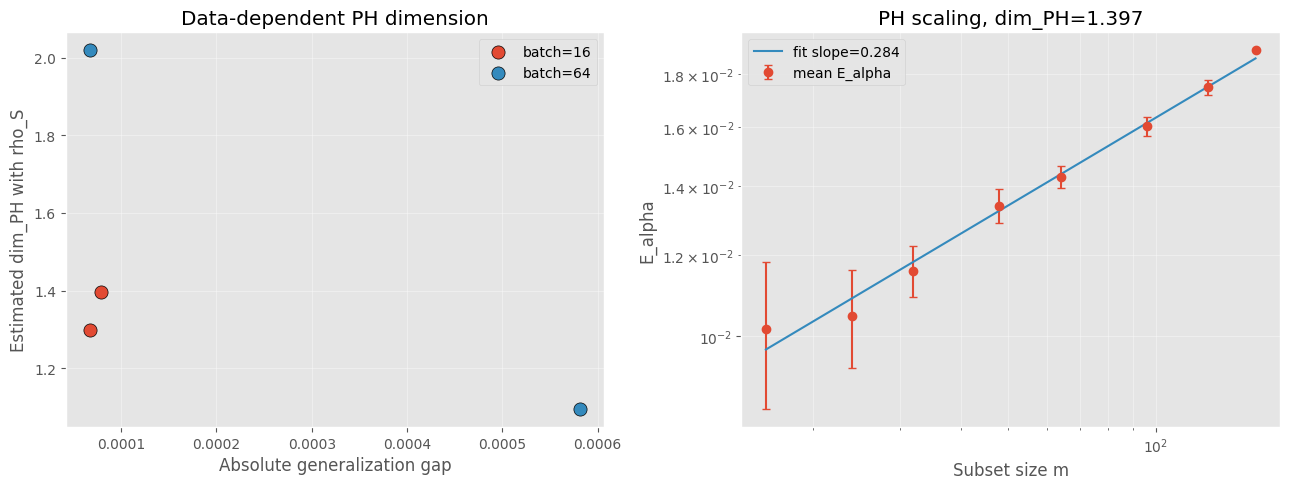

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for batch_size, group in results_df.groupby("batch_size"):
    axes[0].scatter(
        group["generalization_gap"],
        group["dim_ph_rho_s"],
        s=90,
        label=f"batch={batch_size}",
        edgecolor="black",
        linewidth=0.5,
    )
axes[0].set_xlabel("Absolute generalization gap")
axes[0].set_ylabel("Estimated dim_PH with rho_S")
axes[0].set_title("Data-dependent PH dimension")
axes[0].legend()
axes[0].grid(True, alpha=0.35)

first = detailed_results[0]
ph = first["dimensions"]["rho_s_ph"]
mask = ph.mean_e_alpha > 0
axes[1].errorbar(
    ph.subset_sizes[mask],
    ph.mean_e_alpha[mask],
    yerr=ph.std_e_alpha[mask],
    marker="o",
    linestyle="none",
    capsize=3,
    label="mean E_alpha",
)
fit = np.exp(ph.intercept) * ph.subset_sizes[mask] ** ph.slope
axes[1].plot(ph.subset_sizes[mask], fit, label=f"fit slope={ph.slope:.3f}")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Subset size m")
axes[1].set_ylabel("E_alpha")
axes[1].set_title(f"PH scaling, dim_PH={ph.dim_ph:.3f}")
axes[1].legend()
axes[1].grid(True, alpha=0.35, which="both")

plt.tight_layout()
plt.show()


In [10]:
first = detailed_results[0]
rho_s_distance = first["dimensions"]["rho_s_distance"]
death_times = ph_dimension.ph0_death_times_from_distance_matrix(rho_s_distance)

print("rho_S distance matrix shape:", rho_s_distance.shape)
print("first 10 PH0 death times:", death_times[:10])
print("number of PH0 death times:", death_times.size)

first["dimensions"]["rho_s_ph"].as_dict()


rho_S distance matrix shape: (160, 160)
first 10 PH0 death times: [0.0003859  0.00033956 0.00034718 0.00057368 0.00034243 0.0002787
 0.00024013 0.00033666 0.0002608  0.00030253]
number of PH0 death times: 159


{'dim_ph': 1.3970690217629962,
 'alpha': 1.0,
 'slope': 0.28421575138923694,
 'intercept': -5.423960844129983,
 'subset_sizes': array([ 16,  24,  32,  48,  64,  96, 128, 160]),
 'mean_e_alpha': array([0.01014853, 0.01045145, 0.01157846, 0.01339507, 0.0142885 ,
        0.01602067, 0.01749084, 0.01900168]),
 'std_e_alpha': array([0.00166871, 0.00115422, 0.00066206, 0.00051383, 0.00035786,
        0.00034464, 0.00030267, 0.        ]),
 'n_repeats': 12,
 'seed': 7}